In [ ]:
# Copyright 2025 Google LLC
#
# Licensed under the Apache License, Version 2.0 (the "License");
# you may not use this file except in compliance with the License.
# You may obtain a copy of the License at
#
#     http://www.apache.org/licenses/LICENSE-2.0
#
# Unless required by applicable law or agreed to in writing, software
# distributed under the License is distributed on an "AS IS" BASIS,
# WITHOUT WARRANTIES OR CONDITIONS OF ANY KIND, either express or implied.
# See the License for the specific language governing permissions and
# limitations under the License.

In [ ]:
import dotenv
import os

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

import document_processing
import evaluate

# Reload modules to reflect recent edits.
import importlib
importlib.reload(document_processing)
importlib.reload(evaluate)


# Load environment variables.
dotenv.load_dotenv(dotenv_path=".env", override=True)
PROJECT_ID = os.environ.get("GEMINI_PROJECT_ID")
if not PROJECT_ID:
    raise ValueError("GEMINI_PROJECT_ID environment variable must be set.")
LOCATION = os.environ.get("GEMINI_LOCATION", "global")
IMAGE_PATHS = os.environ.get("IMAGE_PATHS", "")
IMAGE_PREFIX = os.environ.get("IMAGE_PREFIX", "")

# Set evaluation parameters.
EVAL_MODEL = "gemini-2.5-flash"
RANDOM_STATE = 42


In [48]:
def plot_confusion_matrix(df, title='Confusion Matrix'):
    # Create a confusion matrix that is ordered by the average exact match score
    # for each class.

    # Extract the ordered list of classes.
    avg_df = df.groupby('reference')['exact_match'].mean().reset_index()
    avg_df = avg_df.sort_values(by='exact_match', ascending=True)

    ordered_classes = avg_df['reference'].tolist()
    extra_preds = [cls for cls in df['response'].unique() if cls not in ordered_classes]
    full_order = ordered_classes + extra_preds

    # Create and order the confusion matrix.
    cm = pd.crosstab(df['reference'], df['response'])
    cm_ordered = cm.reindex(index=full_order, columns=full_order, fill_value=0)

    # Plot the confusion matrix.
    plt.figure(figsize=(10, 8))
    ax = sns.heatmap(cm_ordered, annot=True, fmt='d', cmap='Blues')

    ax.xaxis.tick_top()
    ax.xaxis.set_label_position('top')
    plt.xticks(rotation=90)
    plt.title(title, pad=20)
    plt.ylabel('Actual (Reference)')
    plt.xlabel('Predicted (Response)')

    plt.show()    

    Analyze the intent, visual layout, text content, and structural elements of the document.
    Classify it into exactly one of the following classes based on its distinguishing features.
    Output as JSON in the following format:
    
    "reasoning": "Brief explanation of the key visual cues and keywords found that justify the class",
    "class": "class_name"
    

    Classes:

    {
    "handwritten": "Document entirely handwritten. Process this before other classes",
    "form_10_k": "Annual report of a company",
    "form_10_q": "Quarter report of a company",
    "resume": "CV or work history",
    "file_folder": "Folder cover or label",
    "budget": "Financial forecasts, spreadsheets, or internal expenditure authorizations. IF the document is a fill-in-the-blank form requesting or authorizing money (e.g., 'Contribution Request', 'Account Code', 'Amount: $'), classify as budget. EXCLUDE: Do NOT classify as invoice unless it is a final bill from an external vendor.",
    "inv

/Users/arieljassan/Documents/projects/generative-ai/gemini/use-cases/entity-extraction/evaluate.py:103: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.groupby("reference", group_keys=False).apply(
Computing Metrics for Evaluation Dataset: 100%|██████████| 120/120 [00:04<00:00, 24.97it/s]


[AggregatedMetricResult(
  mean_score=0.7916666666666666,
  metric_name='exact_match',
  num_cases_error=0,
  num_cases_total=120,
  num_cases_valid=120,
  stdev_score=0.407819232762071
)]


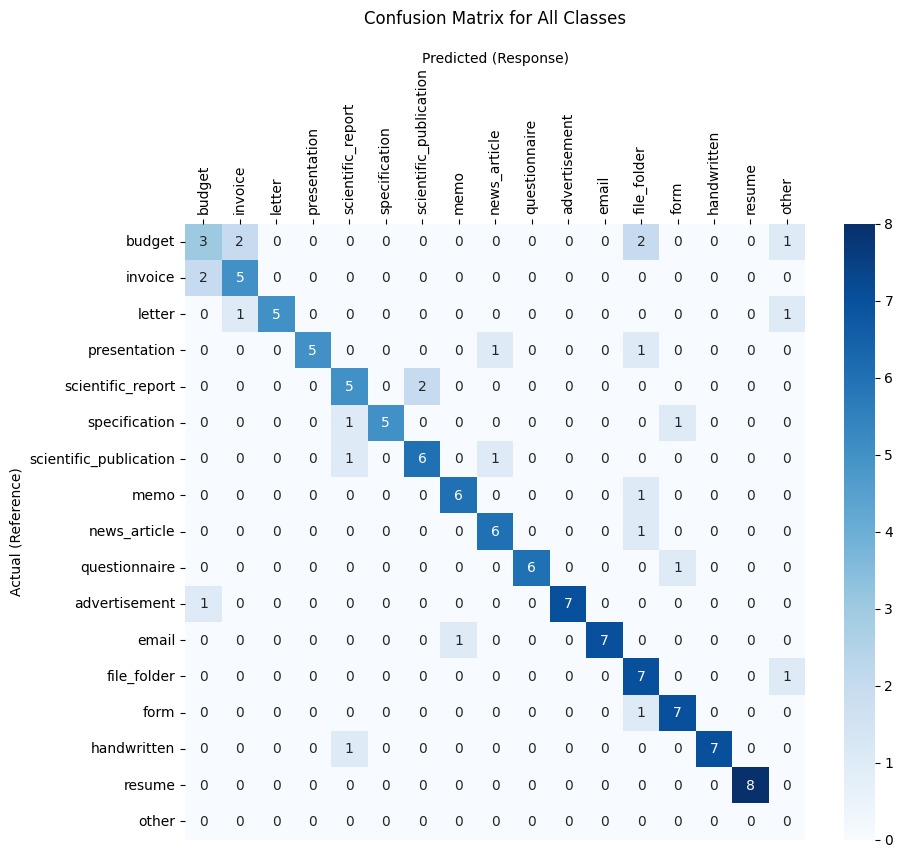

In [67]:
# Run evaluation for document classification task. It will run on the specified 
# sample size and return the evaluation results and a DataFrame with detailed 
# information about each evaluated sample.
importlib.reload(document_processing)
importlib.reload(evaluate)

SAMPLE_SIZE = 120


result, df = (
    evaluate.run_evaluation(
        project_id=PROJECT_ID, 
        location=LOCATION, 
        csv_path=IMAGE_PATHS,
        image_prefix=IMAGE_PREFIX,
        eval_model=EVAL_MODEL,
        sample_size=SAMPLE_SIZE,
        random_state=RANDOM_STATE,
        stratify=True,
    )
)

print(result.summary_metrics)
plot_confusion_matrix(df, title='Confusion Matrix for All Classes')

    Analyze the intent, visual layout, text content, and structural elements of the document.
    Classify it into exactly one of the following classes based on its distinguishing features.
    Output as JSON in the following format:
    
    "reasoning": "Brief explanation of the key visual cues and keywords found that justify the class",
    "class": "class_name"
    

    Classes:

    {
    "budget": "Financial forecasts, spreadsheets, or internal expenditure authorizations. IF the document is a fill-in-the-blank form requesting or authorizing money (e.g., 'Contribution Request', 'Account Code', 'Amount: $'), classify as budget. EXCLUDE: Do NOT classify as invoice unless it is a final bill from an external vendor.",
    "invoice": "Definitive demand for payment for goods/services already delivered. Look for 'Remit To', 'Net 30', 'Terms', 'Tax ID', or 'Please Pay'. If it is an external bill, it is an invoice, even if it has form-like boxes. EXCLUDE: Do NOT classify as budget.",
    

/Users/arieljassan/Documents/projects/generative-ai/gemini/use-cases/entity-extraction/evaluate.py:103: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.groupby("reference", group_keys=False).apply(
Computing Metrics for Evaluation Dataset: 100%|██████████| 60/60 [00:01<00:00, 39.18it/s]


[AggregatedMetricResult(
  mean_score=0.8,
  metric_name='exact_match',
  num_cases_error=0,
  num_cases_total=60,
  num_cases_valid=60,
  stdev_score=0.4033755872716886
)]


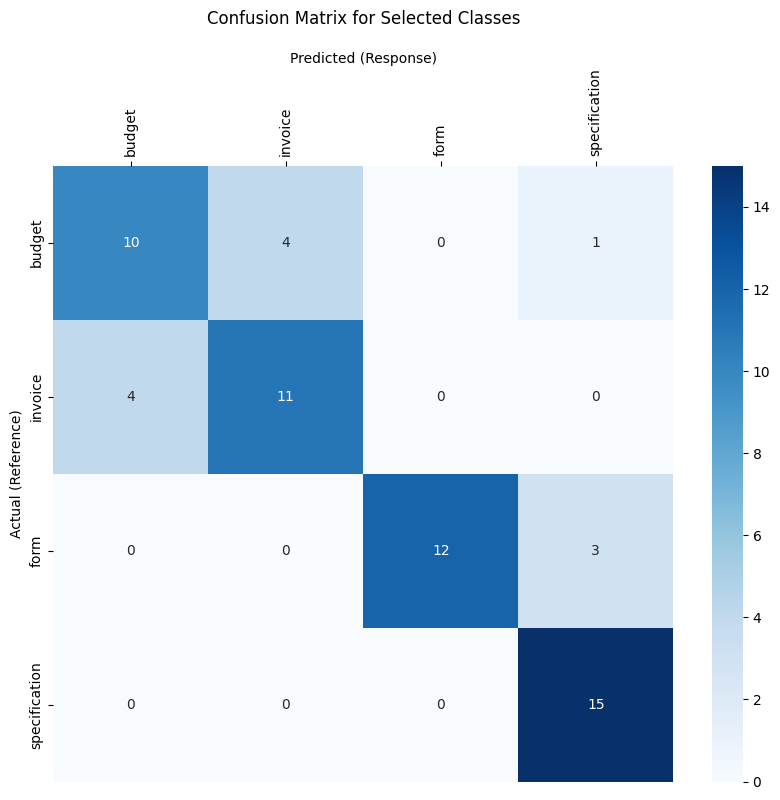

In [68]:
# Run evaluation for a specified set of target classes. This will allow us to 
# focus the evaluation on a subset of classes that are of particular interest.
importlib.reload(document_processing)
importlib.reload(evaluate)

SAMPLE_SIZE = 60


target_classes = [
    "budget", 
    "specification",
    "form",
    "invoice"
]
selected_result, selected_df = (
    evaluate.run_evaluation(
        project_id=PROJECT_ID, 
        location=LOCATION, 
        csv_path=IMAGE_PATHS,
        image_prefix=IMAGE_PREFIX,
        eval_model=EVAL_MODEL,
        sample_size=SAMPLE_SIZE,
        random_state=RANDOM_STATE,
        stratify=True,
        classes=target_classes,
    )
)

print(selected_result.summary_metrics)
plot_confusion_matrix(selected_df, title='Confusion Matrix for Selected Classes')

In [45]:
pd.set_option('display.max_colwidth', None)
selected_df



,img_path,response,reference,exact_match
0,gs://github-repo/generative-ai/gemini/use-cases/entity-extraction/images/budget/2045467868.png,budget,budget,1.0
1,gs://github-repo/generative-ai/gemini/use-cases/entity-extraction/images/budget/ti16352375_2377.png,specification,budget,0.0
2,gs://github-repo/generative-ai/gemini/use-cases/entity-extraction/images/budget/tcal0288700.png,invoice,budget,0.0
3,gs://github-repo/generative-ai/gemini/use-cases/entity-extraction/images/budget/11006870.png,form,budget,0.0
4,gs://github-repo/generative-ai/gemini/use-cases/entity-extraction/images/budget/0000079198.png,budget,budget,1.0
5,gs://github-repo/generative-ai/gemini/use-cases/entity-extraction/images/budget/2048693171.png,budget,budget,1.0
6,gs://github-repo/generative-ai/gemini/use-cases/entity-extraction/images/budget/ti31139030.png,budget,budget,1.0
7,gs://github-repo/generative-ai/gemini/use-cases/entity-extraction/images/budget/11003957.png,invoice,budget,0.0
8,gs://github-repo/generative-ai/gemini/use-cases/entity-extraction/images/budget/tob07809.99.png,invoice,budget,0.0
9,gs://github-repo/generative-ai/gemini/use-cases/entity-extraction/images/budget/24010475.png,form,budget,0.0
